# Design of Experiments

In [33]:
# Import libraries

from doemodels.factorial import Factorial2k #https://github.com/kameelsky/doe-models.git
from doemodels.build import Model

import matplotlib.pyplot as plt
import numpy as np
import sympy as smp
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

## Full factorial design: $2^k$

We have different factors (**Temperature**, **Lubrication**, **Material**, **Brand**) and want to find out which of them has the highest impact on the dependent variable (**Friction**). Conducting full factorial design at two levels (low, high) may anwser this question and provide information about all posible interactions which can occur.

In [34]:
# Define independent variables and factors
independent_variables = ["Temperature", "Lubrication", "Material", "Brand"]
factors = ["A", "B", "C", "D"]

# We create a design, which is an instance of Factorial2k class
design = Factorial2k(columns_input=factors)
design

Factorial2k(columns_input=['A', 'B', 'C', 'D'])

In [35]:
design.DataFrame

,A,B,C,D,AB,AC,AD,BC,BD,CD,ABC,ABD,ACD,BCD,ABCD
Experiments,,,,,,,,,,,,,,,
1,-1,-1,-1,-1,1,1,1,1,1,1,-1,-1,-1,-1,1
2,1,-1,-1,-1,-1,-1,-1,1,1,1,1,1,1,-1,-1
3,-1,1,-1,-1,-1,1,1,-1,-1,1,1,1,-1,1,-1
4,1,1,-1,-1,1,-1,-1,-1,-1,1,-1,-1,1,1,1
5,-1,-1,1,-1,1,-1,1,-1,1,-1,1,-1,1,1,-1
6,1,-1,1,-1,-1,1,-1,-1,1,-1,-1,1,-1,1,1
7,-1,1,1,-1,-1,-1,1,1,-1,-1,-1,1,1,-1,1
8,1,1,1,-1,1,1,-1,1,-1,-1,1,-1,-1,-1,-1
9,-1,-1,-1,1,1,1,-1,1,-1,-1,-1,1,1,1,-1


In [36]:
# Prepare experiments to be conducted
experiments = design.DataFrame.copy()
experiments = experiments[["A", "B", "C", "D"]]
experiments.columns = independent_variables
experiments["Temperature"].replace({-1: "low", 1: "high"}, inplace=True)
experiments["Lubrication"].replace({-1: "oil", 1: "grease"}, inplace=True)
experiments["Material"].replace({-1: "steel", 1: "ceramic"}, inplace=True)
experiments["Brand"].replace({-1: "BMW", 1: "Mercedes"}, inplace=True)
experiments

,Temperature,Lubrication,Material,Brand
Experiments,,,,
1,low,oil,steel,BMW
2,high,oil,steel,BMW
3,low,grease,steel,BMW
4,high,grease,steel,BMW
5,low,oil,ceramic,BMW
6,high,oil,ceramic,BMW
7,low,grease,ceramic,BMW
8,high,grease,ceramic,BMW
9,low,oil,steel,Mercedes


In [37]:
# After conducting experiments we get a response
experiments["Friction"] = [112, 106, 120, 108, 114, 108, 123, 110, 113, 105, 121, 109, 114, 108, 121, 110]
experiments

,Temperature,Lubrication,Material,Brand,Friction
Experiments,,,,,
1,low,oil,steel,BMW,112
2,high,oil,steel,BMW,106
3,low,grease,steel,BMW,120
4,high,grease,steel,BMW,108
5,low,oil,ceramic,BMW,114
6,high,oil,ceramic,BMW,108
7,low,grease,ceramic,BMW,123
8,high,grease,ceramic,BMW,110
9,low,oil,steel,Mercedes,113


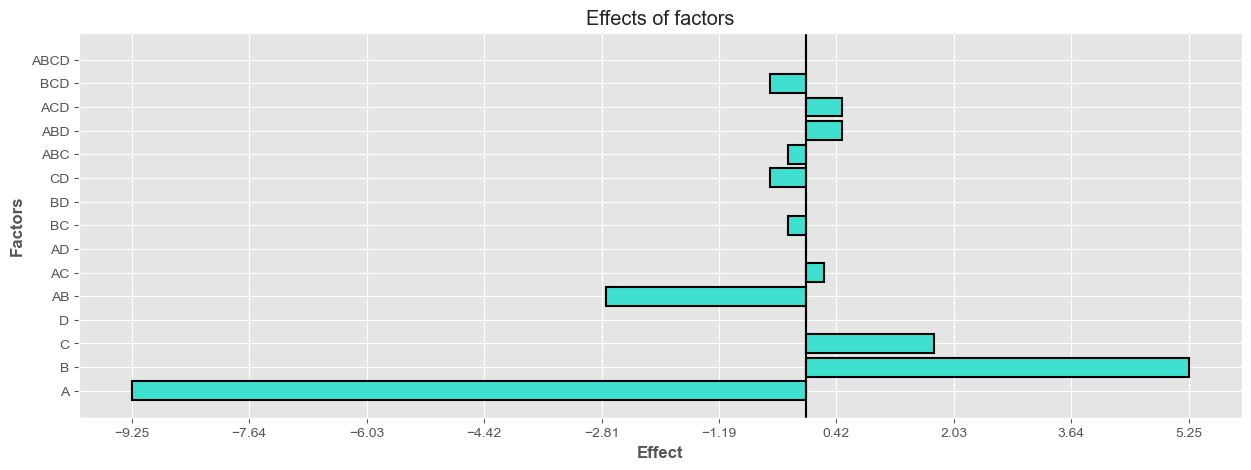

In [38]:
# Plot a graph of effects
design.effects(response=experiments["Friction"], graph=True)

In [39]:
design.effects_table

,A,B,C,D,AB,AC,AD,BC,BD,CD,ABC,ABD,ACD,BCD,ABCD
Response,-9.25,5.25,1.75,0.0,-2.75,0.25,0.0,-0.25,0.0,-0.5,-0.25,0.5,0.5,-0.5,0.0


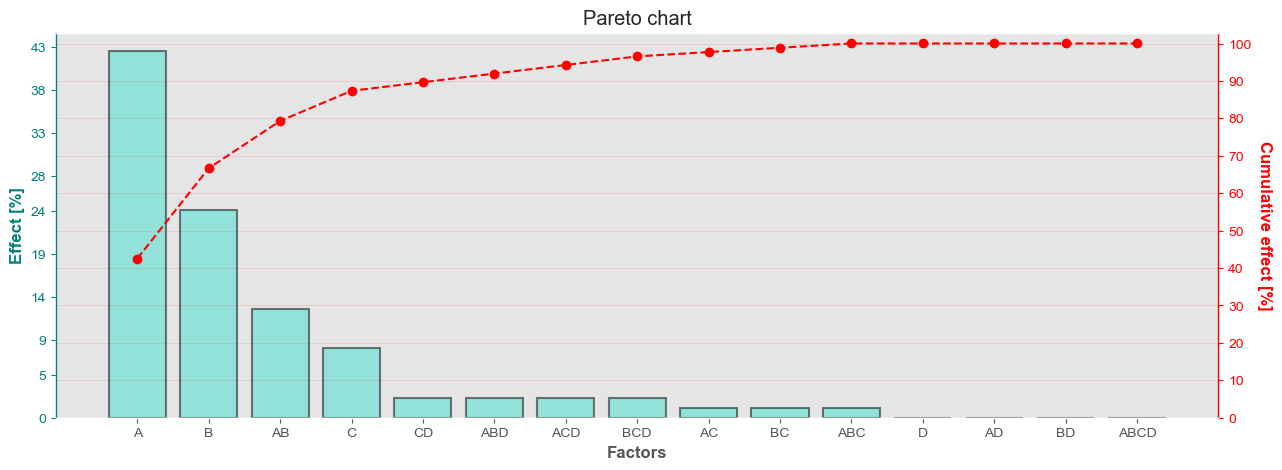

In [40]:
# Pareto chart
design.pareto(graph=True)

In [41]:
design.pareto_table

,Response,%,cum_sum_%
A,-9.25,42.53,42.53
B,5.25,24.14,66.67
AB,-2.75,12.64,79.31
C,1.75,8.05,87.36
CD,-0.50,2.30,89.66
ABD,0.50,2.30,91.96
ACD,0.50,2.30,94.26
BCD,-0.50,2.30,96.56
AC,0.25,1.15,97.71
BC,-0.25,1.15,98.86


Now we will build a model to predict the friction.

In [42]:
experiments.columns

Index(['Temperature', 'Lubrication', 'Material', 'Brand', 'Friction'], dtype='object')

In [43]:
model1 = Model(formula="Friction ~ Temperature*Lubrication + Material + Brand", data=experiments)
model2= Model(formula="Friction ~ Temperature*Lubrication + Material", data=experiments)
model3 = Model(formula="Friction ~ Temperature*Lubrication", data=experiments)

In [44]:
model1.metrics_table.round(2)

,Friction ~ Temperature*Lubrication + Material + Brand
R squared (adjusted),0.99
R squared,0.99
BIC,42.61
AIC,37.97
RMSE,0.54


In [45]:
model2.metrics_table.round(2)

,Friction ~ Temperature*Lubrication + Material
R squared (adjusted),0.99
R squared,0.99
BIC,39.84
AIC,35.97
RMSE,0.54


In [46]:
model3.metrics_table.round(2)

,Friction ~ Temperature*Lubrication
R squared (adjusted),0.96
R squared,0.97
BIC,57.47
AIC,54.38
RMSE,1.03


Removing **Brand** from **Model 1** diminished BIC, leaving RMSE and $R^2$ intact. It seems that **Brand** has no influence on predicting **Friction**.

In [47]:
sm.stats.anova_lm(model2.statsmodel, model1.statsmodel)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,11.0,4.75,0.0,NaN,NaN,NaN
1,10.0,4.75,1.0,-0.0,-0.0,1.0


Additionaly, ANOVA confirmed that **Model 2** is not significantly better in explaining the variance of data.

In [48]:
model2.anova_table

,DF,Sum of Squares,Mean square,F,Prob(F)
Temperature,1.0,342.25,342.250000,792.578947,1.330209e-11
Lubrication,1.0,110.25,110.250000,255.315789,5.849164e-09
Material,1.0,12.25,12.250000,28.368421,2.424761e-04
Temperature:Lubrication,1.0,30.25,30.250000,70.052632,4.240143e-06
Model,4.0,495.00,123.750000,286.578947,4.876188e-11
Error,11.0,4.75,0.431818,NaN,NaN


In [49]:
model2.coefficients_table.round(3)

,Coefficient,Std. Error,t,Prob(t),[0.025,0.975]
Intercept,110.125,0.367,299.785,0.0,109.316,110.934
Temperature[T.low],12.000,0.465,25.825,0.0,10.977,13.023
Lubrication[T.oil],-2.500,0.465,-5.380,0.0,-3.523,-1.477
Material[T.steel],-1.750,0.329,-5.326,0.0,-2.473,-1.027
Temperature[T.low]:Lubrication[T.oil],-5.500,0.657,-8.370,0.0,-6.946,-4.054


ANOVA confirmed that all factors in Model 2 are significant in explaining the variance of the data. Additionally all coefficients in the model are significantly different from 0. Therefore the model we can propose is as follows:

$Friction = 110.125 + 12*Temperature_{low} - 2.5 * Lubrication_{oil} - 1.75 * Material_{steel} - 5.5 * Temperature_{low} * Lubrication_{oil}$

In principle we can conclude that to dominish the friction we should have oil and steel as lubrication and material, respectively. Also higher temperature reduces friction.

In [50]:
Thigh = model2.statsmodel.predict({"Temperature": "high", "Lubrication": "oil", "Material": "steel"}).values[0].round(2)
Tlow = model2.statsmodel.predict({"Temperature": "low", "Lubrication": "oil", "Material": "steel"}).values[0].round(2)

print(f"Using steel as a material and oil for lubrication, at high temperatures we expect to reach friction: {Thigh}")
print(f"Using steel as a material and oil for lubrication, at low temperatures we expect to reach friction: {Tlow}")

Using steel as a material and oil for lubrication, at high temperatures we expect to reach friction: 105.88
Using steel as a material and oil for lubrication, at low temperatures we expect to reach friction: 112.38


# Fractional factorial design: $2^{k-n}$

Can we get similiar conclusions, but reduce the number of experiments by half? We can perform fractional factorial design $2^{4-1}_{IV}$. Resolution $IV$ indicates that some of main effects are aliased by $3^{rd}$ order interactions, and $2^{nd}$ order interactions are aliased with other $2^{nd}$ order interactions.

In [51]:
# Define independent variables and factors
independent_variables = ["Temperature", "Lubrication", "Material", "Brand"]
factors = ["A", "B", "C", "D"]

# We create a design, which is an instance of Factorial2k class
design = Factorial2k(columns_input=factors)

# We create design I=ABCD
design.fractional(principal_fraction="ABCD")

In [52]:
# Dictionary of aliases
design.aliases

{'A': ['BCD'],
 'B': ['ACD'],
 'C': ['ABD'],
 'D': ['ABC'],
 'AB': ['CD'],
 'AC': ['BD'],
 'AD': ['BC'],
 'BC': ['AD'],
 'BD': ['AC'],
 'CD': ['AB'],
 'ABC': ['D'],
 'ABD': ['C'],
 'ACD': ['B'],
 'BCD': ['A']}

In [53]:
design.DataFrame_AntiAliased

,A,B,C,D,AB,AC,AD
Experiments,,,,,,,
1,-1,-1,-1,-1,1,1,1
2,1,1,-1,-1,1,-1,-1
3,1,-1,1,-1,-1,1,-1
4,-1,1,1,-1,-1,-1,1
5,1,-1,-1,1,-1,-1,1
6,-1,1,-1,1,-1,1,-1
7,-1,-1,1,1,1,-1,-1
8,1,1,1,1,1,1,1


In [54]:
experiments = design.DataFrame_AntiAliased.copy()
experiments = experiments[["A", "B", "C", "D"]]
experiments.columns = independent_variables
experiments["Temperature"].replace({-1: "low", 1: "high"}, inplace=True)
experiments["Lubrication"].replace({-1: "oil", 1: "grease"}, inplace=True)
experiments["Material"].replace({-1: "steel", 1: "ceramic"}, inplace=True)
experiments["Brand"].replace({-1: "BMW", 1: "Mercedes"}, inplace=True)
experiments

,Temperature,Lubrication,Material,Brand
Experiments,,,,
1,low,oil,steel,BMW
2,high,grease,steel,BMW
3,high,oil,ceramic,BMW
4,low,grease,ceramic,BMW
5,high,oil,steel,Mercedes
6,low,grease,steel,Mercedes
7,low,oil,ceramic,Mercedes
8,high,grease,ceramic,Mercedes


In [55]:
experiments["Friction"] = [112, 108, 108, 123, 105, 121, 114, 110]
experiments

,Temperature,Lubrication,Material,Brand,Friction
Experiments,,,,,
1,low,oil,steel,BMW,112
2,high,grease,steel,BMW,108
3,high,oil,ceramic,BMW,108
4,low,grease,ceramic,BMW,123
5,high,oil,steel,Mercedes,105
6,low,grease,steel,Mercedes,121
7,low,oil,ceramic,Mercedes,114
8,high,grease,ceramic,Mercedes,110


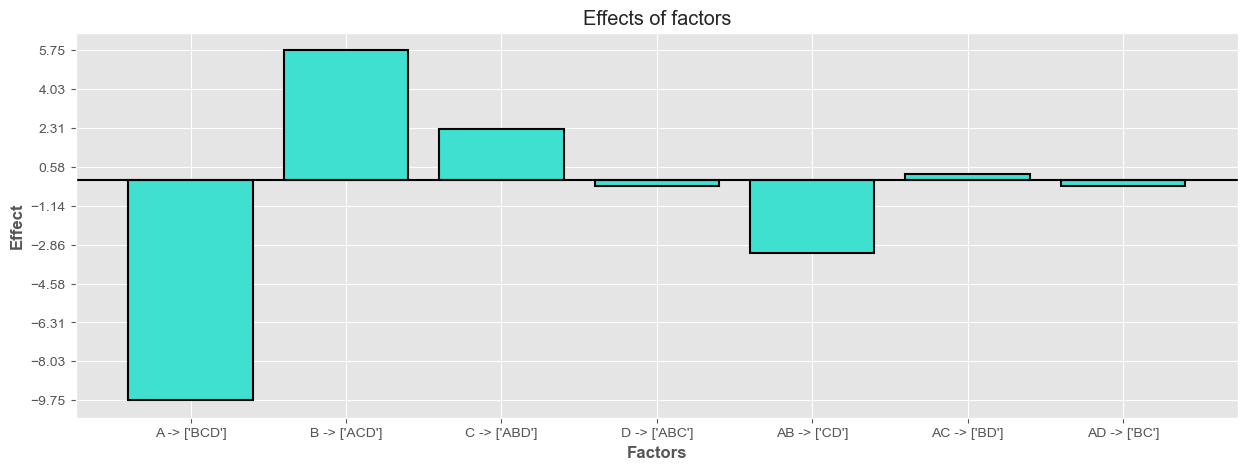

In [56]:
design.effects(response=experiments["Friction"], graph=True)

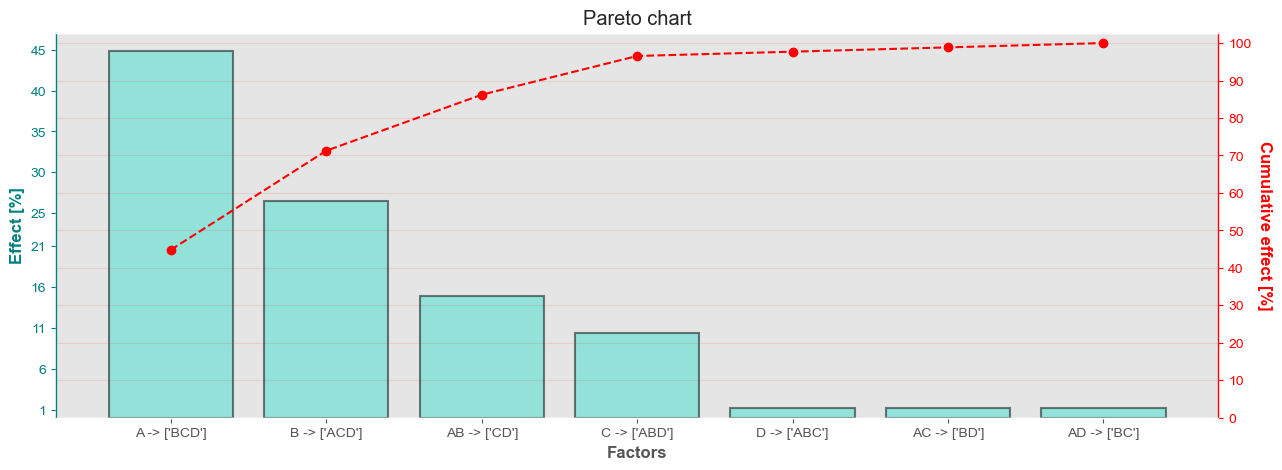

In [57]:
design.pareto(graph=True)

There is no doubt that factor A (Temperature) and B (Lubrication) have high impact on Friction. However Factor AB is aliased with Factor CD. Taking into account that Factor C has less impact on the response we can assume that observed effect derives from interaction of A and B, rather than C and D. 